In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

from src.data.load_data import DataLoader
from src.analytics.hotspot_detection import (
    HotspotDetector,
    DBSCANConfig
)

In [3]:
file_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "jan to may police violation_anonymized791b166.csv"
)

loader = DataLoader(file_path)

df = loader.load()
df = loader.remove_duplicates(df)
df = loader.parse_datetime(df)

2026-06-16 22:58:56.949 | INFO     | src.data.load_data:load:15 - Loading dataset from /Users/meharkapoor7/ParkSense-AI/data/raw/jan to may police violation_anonymized791b166.csv
2026-06-16 22:58:57.742 | INFO     | src.data.load_data:load:27 - Loaded dataset with shape (298450, 24)
2026-06-16 22:58:57.990 | INFO     | src.data.load_data:remove_duplicates:44 - Removed 0 duplicates.


In [9]:
print(PROJECT_ROOT)

/Users/meharkapoor7/ParkSense-AI


In [10]:
processed_path = PROJECT_ROOT / "data" / "processed"

print(processed_path)
print(processed_path.exists())

/Users/meharkapoor7/ParkSense-AI/data/processed
True


In [21]:
parking_df = df.copy()

print(parking_df.shape)

(298450, 24)


In [22]:
parking_df.to_pickle(
    processed_path / "parking_violations.pkl"
)

print("Saved successfully!")

Saved successfully!


In [23]:
import pandas as pd

test_df = pd.read_pickle(
    processed_path / "parking_violations.pkl"
)

print(test_df.shape)

(298450, 24)


In [25]:
from src.data.load_data import DataLoader
from src.data.preprocess import DataPreprocessor
from src.data.feature_engineering import FeatureEngineer
df = loader.load()
df = loader.remove_duplicates(df)
df = loader.parse_datetime(df)

DataPreprocessor.validate_schema(df)

df = DataPreprocessor.remove_invalid_coordinates(df)

df = FeatureEngineer.add_temporal_features(df)

df = FeatureEngineer.parse_violation_types(df)

print(df.shape)
print(type(df["violation_type"].iloc[0]))
print(df["violation_type"].iloc[0])

2026-06-16 23:06:25.384 | INFO     | src.data.load_data:load:15 - Loading dataset from /Users/meharkapoor7/ParkSense-AI/data/raw/jan to may police violation_anonymized791b166.csv
2026-06-16 23:06:26.183 | INFO     | src.data.load_data:load:27 - Loaded dataset with shape (298450, 24)
2026-06-16 23:06:26.415 | INFO     | src.data.load_data:remove_duplicates:44 - Removed 0 duplicates.


(298450, 29)
<class 'list'>
['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']


In [ ]:
processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

df.to_pickle(
    processed_path
    / "parking_violations.pkl"
)

print("Saved successfully!")

Saved successfully!


In [27]:
test_df = pd.read_pickle(
    processed_path
    / "parking_violations.pkl"
)

print(test_df.shape)

(298450, 29)


In [28]:
print(df.shape)

df[["latitude", "longitude"]].describe()

(298450, 29)


,latitude,longitude
count,298450.000000,298450.000000
mean,12.980802,77.600512
std,0.049732,0.050518
min,12.802667,77.442553
25%,12.963331,77.571198
50%,12.977284,77.584114
75%,12.997467,77.621529
max,13.293684,77.771735


In [29]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df.longitude,
        df.latitude
    ),
    crs="EPSG:4326"
)

gdf.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp,hour,day,month,weekday,is_weekend,geometry
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[WRONG PARKING, PARKING NEAR ROAD CROSSING]","[112,104]",2023-11-20 00:28:46+00:00,...,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00,0.0,20.0,11.0,Monday,0,POINT (77.61866 12.92556)
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,[NO PARKING],[113],2023-11-24 22:46:46+00:00,...,NaN,NaN,NaN,NaN,22.0,24.0,11.0,Friday,0,POINT (77.70078 12.90546)
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[WRONG PARKING, PARKING IN A MAIN ROAD]","[112,107]",2023-11-20 00:27:46+00:00,...,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00,0.0,20.0,11.0,Monday,0,POINT (77.6185 12.92545)
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,[NO PARKING],[113],2023-11-16 06:47:46+00:00,...,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00,6.0,16.0,11.0,Thursday,0,POINT (77.51862 12.95652)
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,[NO PARKING],[113],2023-11-22 04:56:46+00:00,...,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00,4.0,22.0,11.0,Wednesday,0,POINT (77.58055 12.97777)


In [30]:
detector = HotspotDetector(
    DBSCANConfig(
        eps_meters=50,
        min_samples=20
    )
)

hotspot_df = detector.detect(df)

hotspot_df["hotspot_id"].value_counts().head(20)

hotspot_id
 2      56252
 3      25246
-1      19182
 35     10269
 10     10167
 5       9749
 70      8392
 37      8195
 62      5402
 25      4759
 31      4719
 7       4154
 48      3304
 19      2985
 118     2762
 29      2687
 40      2483
 17      2436
 107     2245
 128     2144
Name: count, dtype: int64

In [31]:
n_hotspots = (
    hotspot_df["hotspot_id"].nunique()
    - (1 if -1 in hotspot_df["hotspot_id"].unique() else 0)
)

print(f"Detected hotspots: {n_hotspots}")

Detected hotspots: 606


In [32]:
hotspots = (
    hotspot_df[
        hotspot_df["hotspot_id"] != -1
    ]
    .groupby("hotspot_id")
    .agg(
        violations=("id", "count"),
        mean_lat=("latitude", "mean"),
        mean_lon=("longitude", "mean"),
        unique_locations=("location", "nunique")
    )
    .sort_values(
        "violations",
        ascending=False
    )
)

hotspots.head(20)

,violations,mean_lat,mean_lon,unique_locations
hotspot_id,,,,
2,56252,12.972535,77.577615,572
3,25246,12.981959,77.608041,209
35,10269,13.010292,77.553345,142
10,10167,12.933379,77.690166,82
5,9749,12.999128,77.549224,169
70,8392,12.974458,77.547329,104
37,8195,13.002360,77.570659,151
62,5402,13.071053,77.587946,25
25,4759,13.185415,77.680090,8


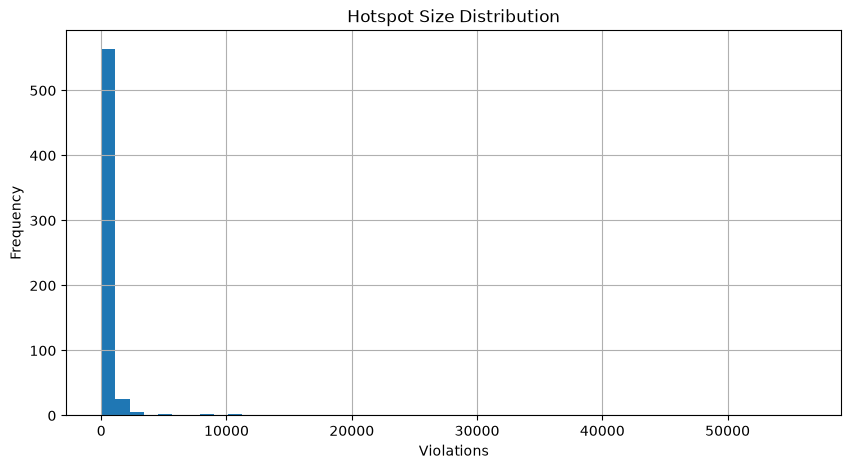

In [33]:
hotspots["violations"].hist(
    bins=50,
    figsize=(10, 5)
)

plt.xlabel("Violations")
plt.ylabel("Frequency")
plt.title("Hotspot Size Distribution")
plt.show()

In [34]:
largest_hotspot = (
    hotspot_df["hotspot_id"]
    .value_counts()
    .idxmax()
)

largest_df = hotspot_df[
    hotspot_df["hotspot_id"] == largest_hotspot
]

largest_df["location"].value_counts().head(20)

location
5th Main Road, Kempe Gowda Circle, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)             2604
3rd Cross Road, Kempegowda Extension, Chickpete, Bengaluru, Karnataka. Pin-560009 (India)             2315
Mysore Road, Sri Krishna Rajendra Market, Chickpete, Bengaluru, Karnataka. Pin-560002 (India)         2122
Subedar Chatram Road, RK Puram, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)                1940
6th Main Road, RK Puram, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)                       1797
Pailwan M Krishnappa Road, Shoukath Mohalla, Nagartapete, Bengaluru, Karnataka. Pin-560002 (India)    1529
KR Main Road, City Market Circle, Bengaluru, Karnataka. Pin-560002 (India)                            1316
AS Char Main Road, Chickpet Circle, Chickpete, Bengaluru, Karnataka. Pin-560053 (India)               1274
Subedar Chatram Road, AT Extension, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)            1219
Silver Jubilee Park Road, Ci

In [36]:
hotspots.to_pickle(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hotspots.pkl"
)

print("Hotspots saved successfully!")

Hotspots saved successfully!


In [37]:
hotspots = pd.read_pickle(
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hotspots.pkl"
)

hotspots.head()

,violations,mean_lat,mean_lon,unique_locations
hotspot_id,,,,
2,56252,12.972535,77.577615,572
3,25246,12.981959,77.608041,209
35,10269,13.010292,77.553345,142
10,10167,12.933379,77.690166,82
5,9749,12.999128,77.549224,169


In [39]:
hotspots.shape[0]

606

In [40]:
processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

processed_path.mkdir(
    parents=True,
    exist_ok=True
)

hotspot_df.to_pickle(
    processed_path
    / "hotspot_df.pkl"
)

hotspots.to_pickle(
    processed_path
    / "hotspots.pkl"
)

print("Saved successfully!")

Saved successfully!
